# Airbnb Reviews Sentiment Analysis

## 1.  Project Introduction

Sentiment Analysis is a Natural Language Processing (NLP) technique used to identify the emotional tone expressed in textual data. It helps classify customer feedback into categories such as positive, negative, and neutral.

In this project, Airbnb review data from Paris is analyzed to understand customer opinions and identify sentiment patterns in guest feedback. The reviews are processed and analyzed using NLP techniques to determine the overall sentiment expressed by customers.

The analysis aims to convert unstructured customer reviews into meaningful insights that can help understand customer satisfaction and identify areas that may require improvement.

## 2. Project Objective

The main objectives of this project are:

- To analyze Airbnb customer reviews from Paris.
- To preprocess and clean textual review data.
- To classify reviews into positive, negative, and neutral sentiments.
- To determine the overall sentiment distribution of customer feedback.
- To identify common themes in positive and negative reviews.
- To visualize sentiment patterns.
- To derive meaningful business insights from customer feedback.


## 3. Research Questions

The sentiment analysis aims to answer the following questions:

1. What is the overall distribution of positive, neutral, and negative Airbnb reviews?
2. What percentage of reviews falls into each sentiment category?
3. What are the most frequently mentioned words in customer reviews?
4. What are the most frequently mentioned words in positive reviews?
5. What are the most frequently mentioned words in negative reviews?

## 4. Dataset Description

The dataset contains Airbnb guest reviews from listings in Paris.

The main textual field used for sentiment analysis is the `comments` column, which contains written feedback provided by guests about their Airbnb experience.

The dataset contains multilingual reviews, including English and other languages. For this project, the analysis will focus on the available review text and apply sentiment analysis to the selected review sample.

## 5. Tools and Technologies

The following tools and libraries are used in this project:

- Python – Programming language for data analysis.
- Pandas – Data loading and data manipulation.
- NumPy – Numerical operations.
- NLTK – Natural Language Processing.
- VADER – Lexicon-based sentiment analysis.
- Matplotlib – Data visualization.
- Seaborn – Statistical visualization.
- Jupyter Notebook – Development and documentation environment.
- Langdetect – Language detection for identifying English-language reviews.

## 6. Project Workflow

The project follows the following steps:

1. Import required libraries.
2. Load the Airbnb reviews dataset.
3. Inspect the dataset structure.
4. Clean the review data.
5. Preprocess the review text.
6. Apply VADER sentiment analysis.
7. Classify reviews as Positive, Negative, or Neutral.
8. Analyze the sentiment distribution.
9. Identify common words and themes.
10. Visualize the sentiment results.
11. Derive observations and business insights.
12. Present the final conclusion.

## 7. Import Required Libraries

The required Python libraries are imported for data manipulation, text processing, sentiment analysis, and visualization.

In [45]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

## 8. Load the Dataset

The Airbnb reviews dataset is loaded into a Pandas DataFrame for further analysis.

In [46]:
df = pd.read_csv("reviews.csv")

## 9. Dataset Inspection

The structure and basic characteristics of the dataset are examined to understand the available variables and identify potential data-quality issues.

In [47]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (2404369, 6)

Column Names:
Index(['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments'], dtype='str')

Missing Values:
listing_id         0
id                 0
date               0
reviewer_id        0
reviewer_name      2
comments         147
dtype: int64


In [48]:
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,114543,66563271,2016-03-23,27034351,Renaud,"Tres bon accueil, apprtement agreable et tres ..."
1,114543,67236527,2016-03-27,30020827,Cindy,"Appartement impeccablement propre, spacieux où..."
2,114543,67688740,2016-03-30,10711075,Nassim,Très bel appartement. Fonctionnel et bien pla...
3,114543,67984457,2016-04-01,28203498,Benjamin,Excellent accueil. Frédéric est très sympathiq...
4,114543,69477901,2016-04-11,22098487,Beifith,"Rien à dire... un appartement formidable, le m..."


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2404369 entries, 0 to 2404368
Data columns (total 6 columns):
 #   Column         Dtype
---  ------         -----
 0   listing_id     int64
 1   id             int64
 2   date           str  
 3   reviewer_id    int64
 4   reviewer_name  str  
 5   comments       str  
dtypes: int64(3), str(3)
memory usage: 110.1 MB


## 10. Data Cleaning

Missing review texts are removed because sentiment analysis requires textual content for each observation.

In [50]:
df = df[df["comments"].notna()].copy()

df["comments"] = df["comments"].astype(str)

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (2404222, 6)


## 11. Review Sample
A random sample of up to 10,000 reviews was selected for analysis. After language detection, only English-language reviews were retained for VADER sentiment analysis. 

In [51]:
df = df.sample(n=min(10000, len(df)), random_state=42)

In [52]:
df.shape

(10000, 6)

## Note:
A random sample was used to maintain computational efficiency while retaining a sufficiently large set of reviews for sentiment analysis.

## 12. Language Detection

The review dataset contains feedback written in multiple languages. Since VADER is primarily designed for English text, language detection is performed to identify English-language reviews before applying sentiment analysis.

In [53]:
from langdetect import detect

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

df["Language"] = df["comments"].apply(detect_language)

In [54]:
df["Language"].value_counts()

Language
en         5418
fr         2483
es          532
de          399
it          233
pt          175
nl          155
ko          137
zh-cn        81
ja           43
ru           36
ca           31
da           31
ro           26
unknown      25
no           19
sv           17
pl           17
tr           17
cy           13
id           12
cs           12
he           12
el           11
so           10
uk           10
zh-tw         9
hu            7
fi            5
af            4
tl            4
sl            3
sk            3
vi            2
lv            1
hr            1
sq            1
mk            1
fa            1
ar            1
et            1
bg            1
Name: count, dtype: int64

In [55]:
df = df[df["Language"] == "en"].copy()

In [56]:
print("English Reviews:", len(df))

English Reviews: 5418


## 13. Text Preprocessing
The review text is cleaned by converting it to lowercase and removing HTML tags, URLs, and unnecessary whitespace before sentiment analysis.

In [57]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Review"] = df["comments"].apply(clean_text)

In [58]:
df[["comments", "Clean_Review"]].head(10)

,comments,Clean_Review
808173,Messad was super friendly and responded quickl...,messad was super friendly and responded quickl...
941372,Great little flat in an excellent location. Be...,great little flat in an excellent location. be...
537247,Our family of four was happy to have Valerie's...,our family of four was happy to have valerie's...
1461430,"Paule's flat is just wonderful: quiet, bright,...","paule's flat is just wonderful: quiet, bright,..."
1748507,We enjoyed it and Latif is a great host.,we enjoyed it and latif is a great host.
1428577,Matthieu's cozy apartment was a great find. It...,matthieu's cozy apartment was a great find. it...
1588661,My family and I loved this Airbnb so much! It ...,my family and i loved this airbnb so much! it ...
2285276,Charles’ place was absolutely beautiful and th...,charles’ place was absolutely beautiful and th...
41969,"Frank is the ideal host - so accommodating, an...","frank is the ideal host - so accommodating, an..."
1445156,This was a lovely place! Perfect for two peopl...,this was a lovely place! perfect for two peopl...


## 14. Sentiment Analysis Using VADER

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon-based sentiment analysis tool available through NLTK. It calculates sentiment scores based on the emotional intensity of the text.

The compound score is used to determine the overall sentiment of each review.

In [59]:
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\adilw\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 15. Calculate Sentiment Scores

VADER sentiment scores are calculated for each review. The compound score represents the overall sentiment intensity of the review.

In [60]:
df["Sentiment_Score"] = df["Clean_Review"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [61]:
df[["Clean_Review", "Sentiment_Score"]].head(10)

,Clean_Review,Sentiment_Score
808173,messad was super friendly and responded quickl...,0.9535
941372,great little flat in an excellent location. be...,0.9728
537247,our family of four was happy to have valerie's...,0.9217
1461430,"paule's flat is just wonderful: quiet, bright,...",0.9741
1748507,we enjoyed it and latif is a great host.,0.8126
1428577,matthieu's cozy apartment was a great find. it...,0.9752
1588661,my family and i loved this airbnb so much! it ...,0.9684
2285276,charles’ place was absolutely beautiful and th...,0.9038
41969,"frank is the ideal host - so accommodating, an...",0.8122
1445156,this was a lovely place! perfect for two peopl...,0.9794


## 16. Sentiment Classification

The reviews are classified into three categories based on their compound sentiment score:

- Positive
- Neutral
- Negative

In [62]:
def classify_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Sentiment_Score"].apply(classify_sentiment)

In [63]:
df[["comments", "Sentiment_Score", "Sentiment"]].head(10)

,comments,Sentiment_Score,Sentiment
808173,Messad was super friendly and responded quickl...,0.9535,Positive
941372,Great little flat in an excellent location. Be...,0.9728,Positive
537247,Our family of four was happy to have Valerie's...,0.9217,Positive
1461430,"Paule's flat is just wonderful: quiet, bright,...",0.9741,Positive
1748507,We enjoyed it and Latif is a great host.,0.8126,Positive
1428577,Matthieu's cozy apartment was a great find. It...,0.9752,Positive
1588661,My family and I loved this Airbnb so much! It ...,0.9684,Positive
2285276,Charles’ place was absolutely beautiful and th...,0.9038,Positive
41969,"Frank is the ideal host - so accommodating, an...",0.8122,Positive
1445156,This was a lovely place! Perfect for two peopl...,0.9794,Positive


## 17. Research Questions

## Question 1: What is the Overall Sentiment Distribution?

This analysis examines the number of Positive, Neutral, and Negative reviews to understand the overall sentiment expressed by Airbnb guests.

In [64]:
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    5300
Negative      76
Neutral       42
Name: count, dtype: int64


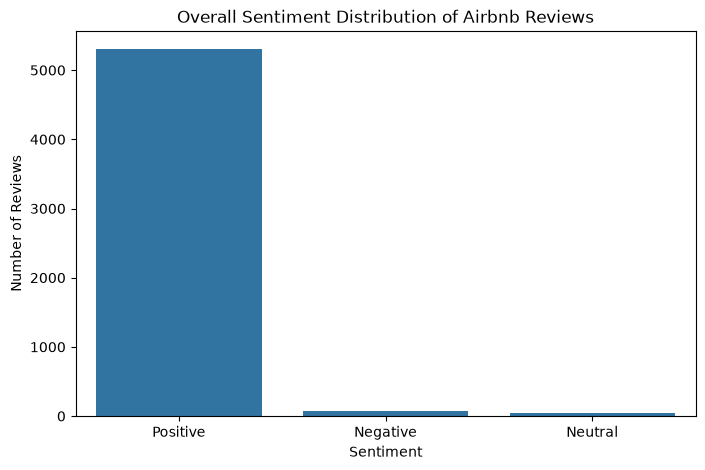

In [65]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Sentiment")

plt.title("Overall Sentiment Distribution of Airbnb Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

## Observation
**The sentiment distribution is highly positive, with 5,290 reviews classified as Positive, compared with 76 Negative and 42 Neutral reviews.**

## Business Insight

**The strong positive sentiment indicates generally favorable guest experiences. The smaller negative segment can be reviewed to identify recurring issues and opportunities for service improvement.**

## Question 2: What Percentage of Reviews Belong to Each Sentiment?

The percentage distribution of Positive, Neutral, and Negative reviews is calculated to provide a clearer understanding of the overall customer sentiment.

In [66]:
sentiment_percentage = (df["Sentiment"].value_counts(normalize=True).mul(100).round(2))

print(sentiment_percentage)

Sentiment
Positive    97.82
Negative     1.40
Neutral      0.78
Name: proportion, dtype: float64


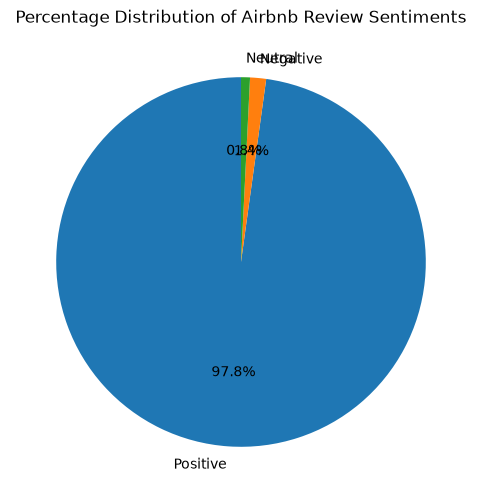

In [67]:
plt.figure(figsize=(8,6))
plt.pie(sentiment_percentage,labels=sentiment_percentage.index,autopct="%1.1f%%",startangle=90)
plt.title("Percentage Distribution of Airbnb Review Sentiments")

plt.show()

## Observation

**Positive reviews represent approximately 97.82% of the analyzed English reviews, followed by Negative reviews at 1.41% and Neutral reviews at 0.78%.**

##  Business Insight

**The high proportion of positive sentiment suggests strong overall customer satisfaction, while the negative reviews provide targeted opportunities for identifying and addressing guest concerns.**

## Question 3: What Are the Most Common Words in Customer Reviews?

The most frequently occurring words are identified to understand the topics and experiences most commonly mentioned by Airbnb guests.

In [68]:
from collections import Counter
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

text = " ".join(df["Clean_Review"])

words = [
    word for word in text.split()
    if word not in stop_words and len(word) > 2
]

word_counts = Counter(words)
common_words = word_counts.most_common(20)

common_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adilw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('great', 2813),
 ('apartment', 2687),
 ('stay', 2155),
 ('place', 1827),
 ('location', 1557),
 ('would', 1405),
 ('everything', 1026),
 ('nice', 1003),
 ('metro', 989),
 ('close', 950),
 ('perfect', 929),
 ('recommend', 885),
 ('paris', 865),
 ('paris.', 833),
 ('good', 823),
 ('easy', 803),
 ('really', 802),
 ('clean', 742),
 ('well', 735),
 ('host', 718)]

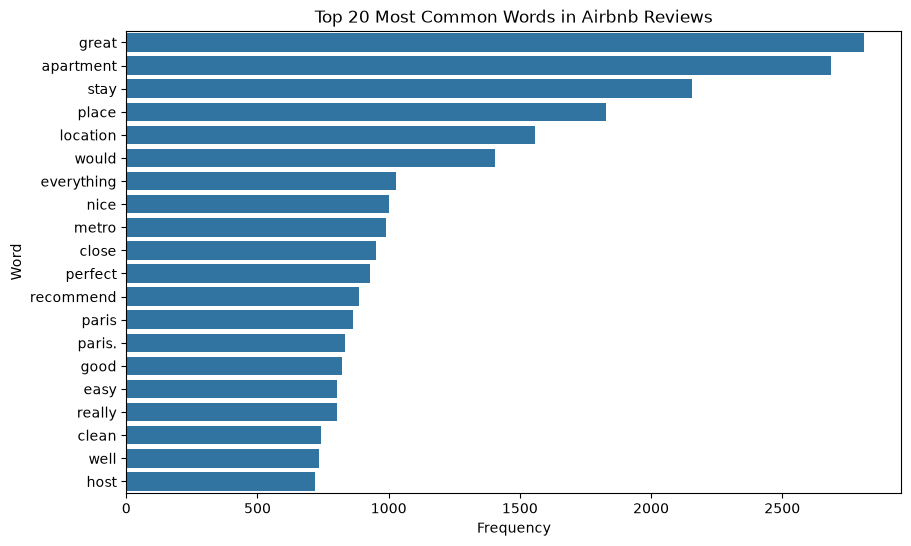

In [69]:
words_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

plt.figure(figsize=(10, 6))

sns.barplot(data=words_df,x="Frequency",y="Word")

plt.title("Top 20 Most Common Words in Airbnb Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

## Observation

**The most frequent words include “great,” “apartment,” “stay,” “location,” “metro,” “clean,” and “host,” indicating that accommodation quality, location, accessibility, and hosting are prominent topics in guest reviews.**

## Business Insight

**Frequently mentioned topics can help hosts understand which aspects of the guest experience receive the most attention and should be maintained or improved.**

## Question 4 :What Are the Most Common Words in Positive Reviews?

The most frequently occurring words in positive reviews are analyzed to identify aspects of the Airbnb experience that guests commonly appreciate.

In [70]:
positive_text = " ".join(df[df["Sentiment"] == "Positive"]["Clean_Review"])

positive_word_text = re.sub(r"[^\w\s]", " ", positive_text.lower())

positive_words = [
    word for word in positive_word_text.split()
    if word not in stop_words and len(word) > 2
]
positive_common = Counter(positive_words).most_common(15)
positive_common

[('apartment', 3398),
 ('great', 3095),
 ('stay', 2965),
 ('location', 2475),
 ('place', 2335),
 ('paris', 2165),
 ('would', 1399),
 ('host', 1345),
 ('clean', 1277),
 ('metro', 1255),
 ('nice', 1147),
 ('perfect', 1147),
 ('everything', 1134),
 ('recommend', 1117),
 ('well', 1007)]

In [71]:
positive_words_df = pd.DataFrame(positive_common,columns=["Word", "Frequency"])
positive_words_df

,Word,Frequency
0,apartment,3398
1,great,3095
2,stay,2965
3,location,2475
4,place,2335
5,paris,2165
6,would,1399
7,host,1345
8,clean,1277
9,metro,1255


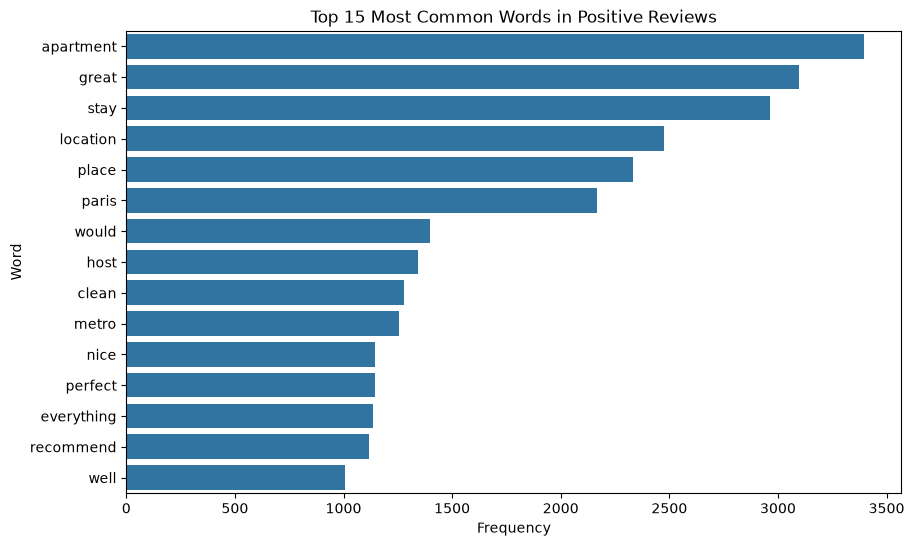

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(data=positive_words_df,x="Frequency",y="Word")
plt.title("Top 15 Most Common Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## Observation

**Positive reviews frequently mention terms such as “great,” “apartment,” “stay,” “location,” and “metro,” indicating recurring aspects of the guest experience.**

## Business Insight

**Positive themes can help hosts identify the aspects of the guest experience that customers value most and should be maintained.**

## Question 5: What Are the Most Common Words in Negative Reviews?

The most frequently occurring words in negative reviews are analyzed to identify recurring issues or areas of concern mentioned by guests.

In [73]:
negative_text = " ".join(df.loc[df["Sentiment"] == "Negative", "Clean_Review"])

negative_word_text = re.sub(r"[^\w\s]", " ", negative_text.lower())

negative_words = [
    word for word in negative_word_text.split()
    if word not in stop_words and len(word) > 2
]
negative_common = Counter(negative_words).most_common(15)
negative_common

[('apartment', 55),
 ('host', 32),
 ('place', 31),
 ('bathroom', 27),
 ('stay', 27),
 ('bed', 25),
 ('location', 24),
 ('paris', 21),
 ('airbnb', 20),
 ('good', 19),
 ('small', 19),
 ('really', 18),
 ('would', 18),
 ('room', 18),
 ('day', 17)]

In [74]:
negative_words_df = pd.DataFrame(negative_common,columns=["Word", "Frequency"])
negative_words_df

,Word,Frequency
0,apartment,55
1,host,32
2,place,31
3,bathroom,27
4,stay,27
5,bed,25
6,location,24
7,paris,21
8,airbnb,20
9,good,19


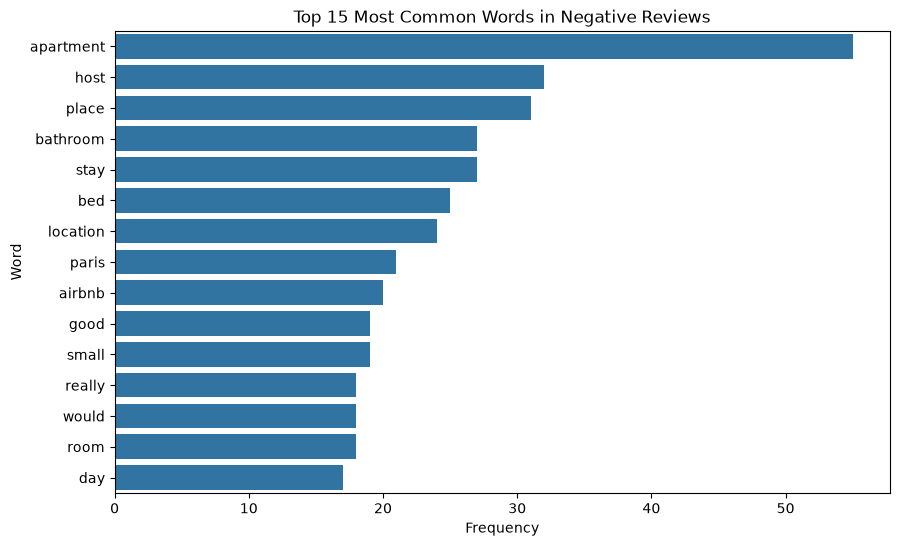

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(data=negative_words_df,x="Frequency", y="Word")
plt.title("Top 15 Most Common Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

## Observation

**The negative reviews frequently mention aspects such as apartments, hosts, bathrooms, beds, and overall stay-related experiences.**

## Business Insight

**These recurring themes can help hosts identify specific aspects of the guest experience that may require attention and improvement.**

## 18. Key Findings

1. The analyzed reviews show a strongly positive overall sentiment.
2. Positive reviews account for the majority of the English-language sample.
3. Frequently occurring words reveal the main topics discussed by Airbnb guests.
4. Positive review themes highlight aspects of the experience that guests value.
5. Negative review themes identify areas that may require improvement.

## 19. Conclusion

The sentiment analysis of Airbnb guest reviews indicates an overwhelmingly positive customer perception within the analyzed English-language sample. VADER-based sentiment classification identified positive, negative, and neutral reviews, while word-frequency and theme analysis highlighted the topics guests discuss most often. Overall, the findings demonstrate how customer reviews can be transformed into actionable insights by identifying customer strengths and areas for improvement.